<h1><font color = 'Green'> <center>GIS Apps in Engineering: Assignment 4</h1>
<h3><font color = 'blue'> <center>Lajuk</h3>

<h5> Problem Statement

The goal is to create a logistic regression model for predicting bridge condition(susceptibility to failure), We shall use Age, ADT
                                                 Material, Reconst as our *independent Variables* We shall recode the lowest bridge rating as Satisfactory (5-9) and Unsatisfactory (0-5)


# Read the 2024 data

1. Create latitudeDD and longitudeDD for plotting

2. Create a new FID (lat_lon)

3. Clean or remove duplicates

4. Recode lowest rating as a binary variable

6. Compute Age

7. Extract the required variables into a new dataframe

8. Perform train-test split

9. Fit the model on the training data

10. Evaluate the model using the testing data

11. Read 2025 data

12. Create new FID using the same concept as in step 3

13. Extract unique bridges in 2025

14. Make prediction using the model fit in step 9 and compare

15. Make plots and maps for visualization and analysis

In [50]:
import geopandas as gpd
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from shapely.geometry import Point, LineString, Polygon
import statsmodels.api as sm
import os

In [51]:
# function to parse lat-lon
def parsell(val, lat=True):
    s = str(val)
    if (len(s) == 8):     # Latitude format (DDMMSSss)
        deg = int(s[:2])
        minx = int(s[2:4])
        secx = int(s[4:]) / 100
    else:                 # Longitude format (DDDMMSSss)
        deg = int(s[:3])
        minx = int(s[3:5])
        secx = int(s[5:]) / 100

    if (lat == True):
        dd = deg + minx / 60 + secx / 3600
    else:                 # Western hemisphere longitudes are negative
        dd = deg + minx / 60 + secx / 3600
        dd = -1 * dd

    return dd


In [52]:
# Vectorized version of parsell
parsellv = np.vectorize(parsell)

In [53]:
path = '/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/Assignment-4/NBI_TX'
os.chdir(path)

In [54]:
#Read 2024 NBI file
fname = "NBI2024.csv" 
a = pd.read_csv(fname, on_bad_lines='skip', dtype="str")
a.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,BRIDGE_LEN_IND_112,SCOUR_CRITICAL_113,FUTURE_ADT_114,YEAR_OF_FUTURE_ADT_115,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,Y,7,200,2035,NaN,Y,68,F,6,169.84
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,Y,8,1,2042,NaN,Y,63,F,6,150.72
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,Y,8,1,2042,NaN,Y,63,G,7,74.4
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,Y,8,150,2042,NaN,Y,63,G,7,91.91
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,Y,8,120,2042,NaN,Y,63,P,4,204.3


In [55]:
a['FID'] = a.LAT_016.astype(str) + "_" + a.LONG_017.astype(str)
a['FID']

0        35185702_101560762
1        29362100_094272880
2        29362940_094254920
3        29365160_094324020
4        29413300_094044860
                ...        
56724    31495329_106183492
56725    32430233_096561253
56726    32424987_096560305
56727    32424560_096561340
56728    29283700_098252680
Name: FID, Length: 56729, dtype: object

In [56]:
a.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,SCOUR_CRITICAL_113,FUTURE_ADT_114,YEAR_OF_FUTURE_ADT_115,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,FID
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,7,200,2035,NaN,Y,68,F,6,169.84,35185702_101560762
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,8,1,2042,NaN,Y,63,F,6,150.72,29362100_094272880
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,8,1,2042,NaN,Y,63,G,7,74.4,29362940_094254920
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,8,150,2042,NaN,Y,63,G,7,91.91,29365160_094324020
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,8,120,2042,NaN,Y,63,P,4,204.3,29413300_094044860


In [57]:
len(a)

56729

In [58]:
# Remove duplicates based on FID
aa = a[~a.duplicated(subset=['FID'], keep=False)].copy()
len(aa)

56571

In [59]:
aa.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,SCOUR_CRITICAL_113,FUTURE_ADT_114,YEAR_OF_FUTURE_ADT_115,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,FID
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,7,200,2035,NaN,Y,68,F,6,169.84,35185702_101560762
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,8,1,2042,NaN,Y,63,F,6,150.72,29362100_094272880
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,8,1,2042,NaN,Y,63,G,7,74.4,29362940_094254920
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,8,150,2042,NaN,Y,63,G,7,91.91,29365160_094324020
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,8,120,2042,NaN,Y,63,P,4,204.3,29413300_094044860


In [79]:
#create a Lat-Lon
latx = aa.loc[:,["LAT_016"]]
aa.loc[:,"LATDD"] = parsellv(latx,lat=True)

In [61]:
lonx = aa.loc[:, "LONG_017"]
aa.loc[:, "LONDD"] = parsellv(lonx, lat=False)

In [62]:
aa.LONDD

0       -101.935450
1        -94.458000
2        -94.430333
3        -94.544500
4        -94.080167
            ...    
56724   -106.309700
56725    -96.936814
56726    -96.934181
56727    -96.937056
56728    -98.424111
Name: LONDD, Length: 56571, dtype: float64

In [63]:
aa.LOWEST_RATING.describe()

count     56571
unique       10
top           7
freq      27960
Name: LOWEST_RATING, dtype: object

In [64]:
aa.LOWEST_RATING.unique()

array(['6', '7', '4', '8', '3', '5', '9', '2', '1', '0'], dtype=object)

In [65]:
Rat = aa.loc[:,["LOWEST_RATING"]].astype(int)
aa["UNSAFE"] = np.where(Rat<6,1,0)

In [66]:
aa.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,FID,LATDD,LONDD,UNSAFE
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,NaN,Y,68,F,6,169.84,35185702_101560762,35.315839,-101.935450,0
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,NaN,Y,63,F,6,150.72,29362100_094272880,29.605833,-94.458000,0
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,NaN,Y,63,G,7,74.4,29362940_094254920,29.608167,-94.430333,0
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,NaN,Y,63,G,7,91.91,29365160_094324020,29.614333,-94.544500,0
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,NaN,Y,63,P,4,204.3,29413300_094044860,29.692500,-94.080167,1


In [67]:
sum(aa.UNSAFE)

4818

In [68]:
len(aa)

56571

<h3> Compute Age

In [69]:
aa.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,FID,LATDD,LONDD,UNSAFE
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,NaN,Y,68,F,6,169.84,35185702_101560762,35.315839,-101.935450,0
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,NaN,Y,63,F,6,150.72,29362100_094272880,29.605833,-94.458000,0
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,NaN,Y,63,G,7,74.4,29362940_094254920,29.608167,-94.430333,0
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,NaN,Y,63,G,7,91.91,29365160_094324020,29.614333,-94.544500,0
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,NaN,Y,63,P,4,204.3,29413300_094044860,29.692500,-94.080167,1


In [93]:
#YEARS_BUILT_027
#YEARS_RECONSTRUCTED_106
yrb = pd.to_numeric(aa.YEAR_BUILT_027, errors ="coerce")
yrc = pd.to_numeric(aa.YEAR_RECONSTRUCTED_106, errors ="coerce")
aa["AGE"] = 2024 - latest_year


NameError: name 'latest_year' is not defined

In [81]:
aa("AGE")=age

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (3455774470.py, line 1)

In [71]:
aa = aa.loc[aa["LATDD"] > 25]
aa.describe()

,LATDD,LONDD,UNSAFE
count,56570.000000,56570.000000,56570.000000
mean,31.224550,-97.512845,0.085169
std,1.815607,2.262591,0.279135
min,25.873389,-106.618869,0.000000
25%,29.800444,-98.434671,0.000000
50%,31.267235,-97.160800,0.000000
75%,32.744215,-95.970334,0.000000
max,36.482353,-93.520178,1.000000


In [72]:
aa.describe()

,LATDD,LONDD,UNSAFE
count,56570.000000,56570.000000,56570.000000
mean,31.224550,-97.512845,0.085169
std,1.815607,2.262591,0.279135
min,25.873389,-106.618869,0.000000
25%,29.800444,-98.434671,0.000000
50%,31.267235,-97.160800,0.000000
75%,32.744215,-95.970334,0.000000
max,36.482353,-93.520178,1.000000


EPSG:4326


<function matplotlib.pyplot.show(close=None, block=None)>

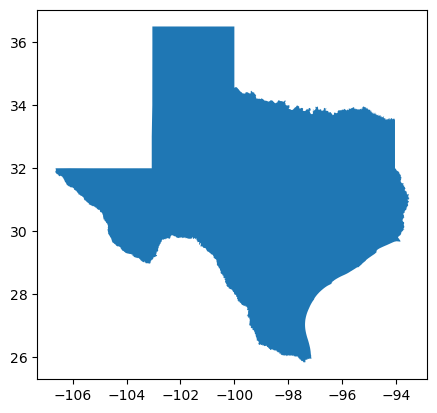

In [86]:
txdis = gpd.read_file("TX_dissolved.gpkg")
txdis = txdis.to_crs(epsg=4326)
print(txdis.crs)
txdis.plot()
plt.show

In [74]:
txdis.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [75]:
from shapely.geometry import Point

In [76]:
bridges = gpd.GeoDataFrame(
    aa,
    geometry=gpd.points_from_xy(aa["LONDD"], aa["LATDD"]),
    crs="EPSG:4326"
)

In [77]:
# Match projection to Texas dissolved map
bridges = bridges.to_crs(txdis.crs)

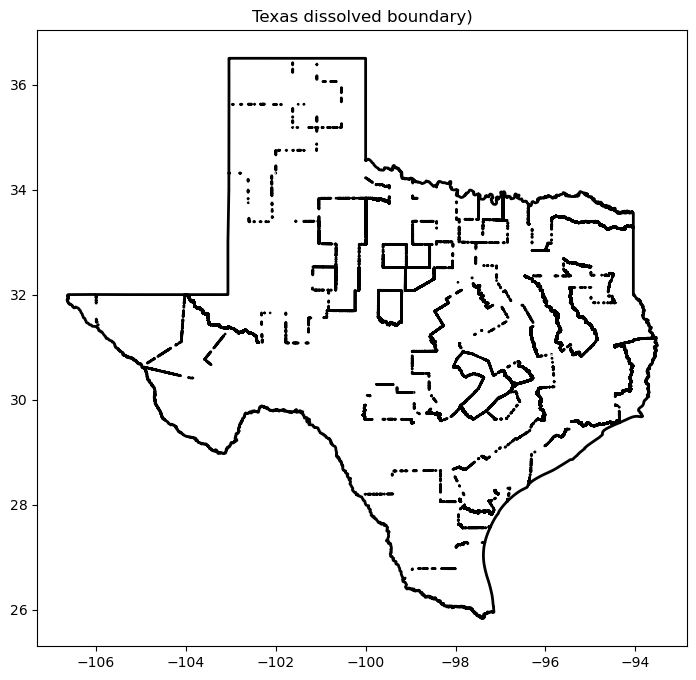

In [84]:
colormap = {0: "blue", 1: "red"}
bridges["color"] = bridges["UNSAFE"].map(colormap)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Texas dissolved boundary
txdis.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)

plt.title("Texas dissolved boundary)")
plt.show()

In [94]:
from shapely.geometry import Polygon

txdis["geometry"] = txdis["geometry"].apply(lambda geom: Polygon(geom.exterior))
txdis = txdis.to_crs(epsg=4326)
txdis.plot( facecolor="none", edgecolor="black", linewidth=2)

<Axes: title={'center': 'Texas dissolved boundary)'}>

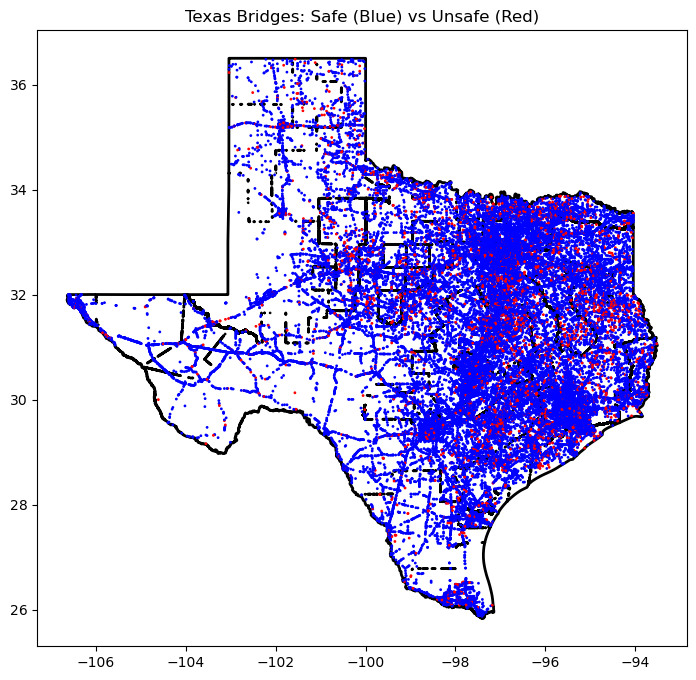

In [78]:
colormap = {0: "blue", 1: "red"}
bridges["color"] = bridges["UNSAFE"].map(colormap)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Texas dissolved boundary
txdis.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)

# Plot bridges with color based on UNSAFE
bridges.plot(ax=ax, color=bridges["color"], markersize=1)

plt.title("Texas Bridges: Safe (Blue) vs Unsafe (Red)")
plt.show()
